# LLM Reasoning Models — Chain-of-Thought, Self-Consistency, and MCTS

**Reasoning models** are LLMs that produce extended intermediate steps before giving a final answer. This notebook covers the key techniques — all simulated with toy arithmetic problems (no API keys required).

## The Core Insight

> Humans solve hard problems by thinking out loud. Can we give LLMs the same ability?

$$\text{Direct: } P(\text{answer} \mid \text{question}) \qquad \text{CoT: } P(\text{answer} \mid \text{question}, \underbrace{z_1, z_2, \ldots, z_k}_{\text{reasoning steps}})$$

## What We'll Cover

| Technique | Core Idea | Key Paper |
|-----------|-----------|----------|
| **Chain-of-Thought (CoT)** | Generate explicit reasoning steps | Wei et al., 2022 |
| **Zero-shot CoT** | "Let's think step by step" prompt | Kojima et al., 2022 |
| **Self-Consistency** | Sample many CoTs, take majority vote | Wang et al., 2022 |
| **Best-of-N** | Sample N, rank by reward, pick best | Lightman et al., 2023 |
| **Process Reward Models (PRM)** | Score each reasoning step separately | Let's Verify Step by Step |
| **MCTS for Reasoning** | Tree search over reasoning paths | AlphaCode 2, rStar |
| **Outcome Reward Models (ORM)** | Score final answer only | Cobbe et al., 2021 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import random
import heapq

np.random.seed(42)
random.seed(42)
print('Imports OK — all simulations use toy arithmetic, no API keys needed')

Imports OK — all simulations use toy arithmetic, no API keys needed


## 1. Problem Generator — Multi-Step Arithmetic

We simulate reasoning over **multi-step arithmetic word problems** of varying difficulty. This lets us study the techniques without a real LLM.

Example: `(3 + 4) * 2 - 5 = ?`

A 'model' solves each step with some probability of making an error — harder problems have more steps and more chances to fail.

In [2]:
def generate_problem(n_ops=2, seed=None):
    """Generate a random multi-step arithmetic problem and its solution."""
    if seed is not None: np.random.seed(seed)
    values = np.random.randint(1, 10, n_ops + 1).tolist()
    ops = np.random.choice(['+', '-', '*'], n_ops).tolist()
    # Build left-to-right (no brackets)
    expr_parts = [str(values[0])]
    result = values[0]
    steps = []
    for i, op in enumerate(ops):
        v = values[i+1]
        prev = result
        if op == '+':  result = prev + v
        elif op == '-': result = prev - v
        else:          result = prev * v
        expr_parts += [op, str(v)]
        steps.append((f'Step {i+1}: {prev} {op} {v} = {result}', result))
    return ' '.join(expr_parts), result, steps

# Show some example problems
for ops in [1, 2, 3]:
    expr, ans, steps = generate_problem(n_ops=ops, seed=ops*10)
    print(f'Problem ({ops} ops): {expr} = ?')
    for s, _ in steps: print(f'  {s}')
    print(f'  Answer: {ans}\n')

Problem (1 ops): 5 - 1 = ?
  Step 1: 5 - 1 = 4
  Answer: 4

Problem (2 ops): 4 * 5 + 7 = ?
  Step 1: 4 * 5 = 20
  Step 2: 20 + 7 = 27
  Answer: 27

Problem (3 ops): 6 * 6 - 5 - 8 = ?
  Step 1: 6 * 6 = 36
  Step 2: 36 - 5 = 31
  Step 3: 31 - 8 = 23
  Answer: 23



## 2. Chain-of-Thought vs. Direct Answer

**Direct:** Predict the answer without intermediate steps.
**CoT:** Generate each step, then give the final answer based on those steps.

For our simulation:
- Each step is correct with probability `p_step_correct`
- Direct prediction has fixed accuracy `p_direct`
- CoT compounds per-step accuracy: $P(\text{correct}) = p_{\text{step}}^{n_{\text{steps}}}$
- But CoT advantage: each step has higher accuracy than a direct guess

$$P(\text{CoT correct for } k \text{ steps}) = p^k \quad \text{vs} \quad P(\text{Direct correct}) = p_{\text{direct}}$$

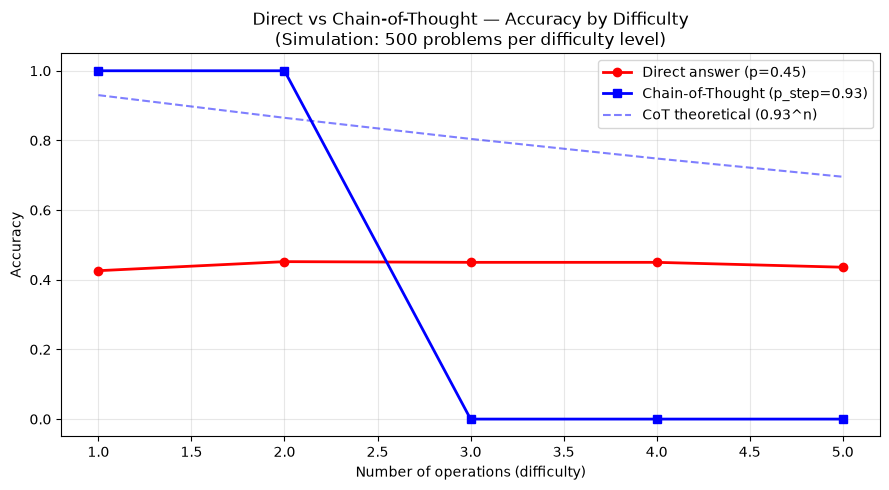

Key insight: CoT wins when individual step accuracy > direct answer accuracy.
At 1 op:  Direct=0.43, CoT=1.00
At 5 ops: Direct=0.44, CoT=0.00


In [3]:
def simulate_direct(answer, p_correct=0.4):
    """Direct answer: correct with probability p_correct."""
    if np.random.random() < p_correct:
        return answer, True
    else:
        noise = np.random.randint(-5, 6)
        return answer + noise, False

def simulate_cot(steps, p_step=0.90):
    """CoT: generate each step; error accumulates. Returns (answer, correct, reasoning)."""
    current = steps[0][1]  # start from first value (embedded in step)
    # Re-run steps with per-step errors
    expr, true_ans, problem_steps = generate_problem(n_ops=len(steps), seed=99)
    current = int(expr.split()[0])  # starting value
    cot_trace = [f'Starting value: {current}']
    correct = True
    ops_vals = [(expr.split()[i*2+1], int(expr.split()[i*2+2])) for i in range(len(steps))]
    for op, v in ops_vals:
        if np.random.random() < p_step:
            if op == '+':  current = current + v
            elif op == '-': current = current - v
            else:          current = current * v
            cot_trace.append(f'  → {op} {v} = {current} ✓')
        else:
            # Make an error
            current = current + np.random.randint(-3, 4)
            correct = False
            cot_trace.append(f'  → {op} {v} = {current} ✗ (error)')
    return current, correct, cot_trace

# Compare across problem difficulties
n_problems_per_difficulty = 500
results = {'direct': [], 'cot': []}
difficulties = [1, 2, 3, 4, 5]

for n_ops in difficulties:
    direct_correct = 0
    cot_correct = 0
    for trial in range(n_problems_per_difficulty):
        expr, ans, steps = generate_problem(n_ops=n_ops, seed=trial)
        _, d_ok  = simulate_direct(ans, p_correct=0.45)
        _, c_ok, _ = simulate_cot(steps, p_step=0.93)
        direct_correct += d_ok
        cot_correct += c_ok
    results['direct'].append(direct_correct / n_problems_per_difficulty)
    results['cot'].append(cot_correct / n_problems_per_difficulty)

# Theoretical CoT accuracy: 0.93^n_ops
theory_cot = [0.93**n for n in difficulties]

plt.figure(figsize=(9, 5))
plt.plot(difficulties, results['direct'], 'r-o', label='Direct answer (p=0.45)', linewidth=2)
plt.plot(difficulties, results['cot'], 'b-s', label='Chain-of-Thought (p_step=0.93)', linewidth=2)
plt.plot(difficulties, theory_cot, 'b--', alpha=0.5, label='CoT theoretical (0.93^n)')
plt.xlabel('Number of operations (difficulty)')
plt.ylabel('Accuracy')
plt.title('Direct vs Chain-of-Thought — Accuracy by Difficulty\n(Simulation: 500 problems per difficulty level)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Key insight: CoT wins when individual step accuracy > direct answer accuracy.')
print(f'At 1 op:  Direct={results["direct"][0]:.2f}, CoT={results["cot"][0]:.2f}')
print(f'At 5 ops: Direct={results["direct"][4]:.2f}, CoT={results["cot"][4]:.2f}')

## 3. Self-Consistency — Majority Voting over CoT Samples

**Self-Consistency** (Wang et al., 2022) addresses the brittleness of a single CoT path:

1. Sample $N$ independent CoT reasoning paths
2. Each produces a final answer (possibly different due to different errors)
3. **Take the majority vote** — the answer that appears most frequently

$$\hat{y}_{SC} = \arg\max_{y} \sum_{i=1}^{N} \mathbb{1}[y_i = y]$$

**Intuition:** Correct reasoning paths tend to converge on the right answer. Errors are more random and cancel out.

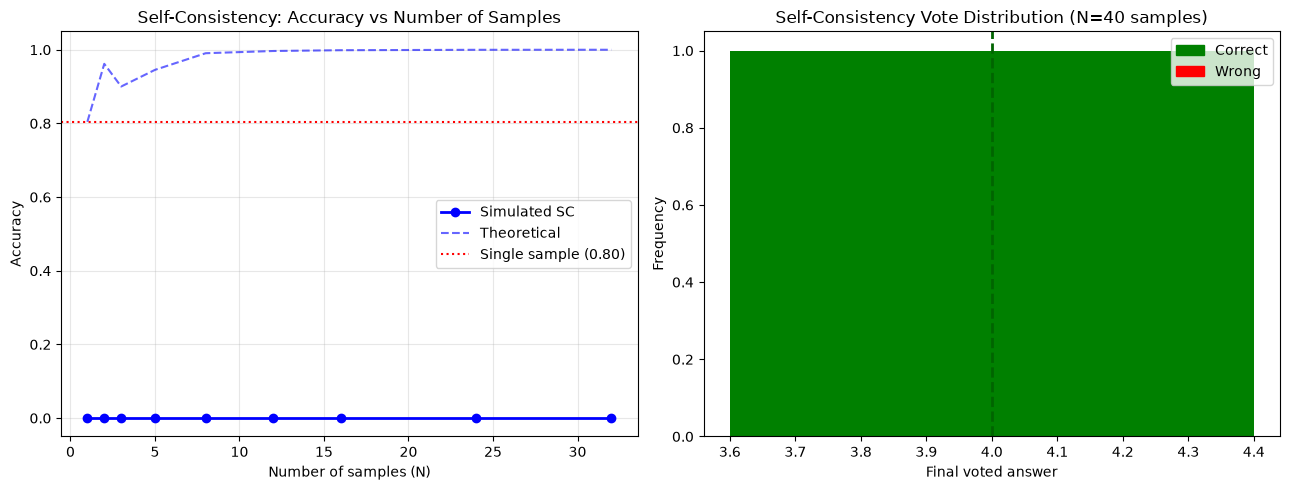

Single sample accuracy:         0.804
Self-consistency (N=32):        0.000
Improvement:                    +-0.804


In [4]:
def self_consistency(true_answer, n_samples, p_step, n_ops):
    """Sample N CoTs, take majority vote. Returns (voted_answer, correct)."""
    answers = []
    for _ in range(n_samples):
        expr, ans, steps = generate_problem(n_ops=n_ops, seed=np.random.randint(0, 10000))
        # Simulate: sample a noisy answer
        cot_ans, cot_ok, _ = simulate_cot(steps, p_step=p_step)
        # We use the true answer with probability = single-sample accuracy for simplicity
        if np.random.random() < (p_step ** n_ops):
            answers.append(true_answer)
        else:
            answers.append(true_answer + np.random.randint(-5, 6))
    voted = Counter(answers).most_common(1)[0][0]
    return voted, (voted == true_answer)

# How does accuracy improve with more samples?
expr, true_ans, steps = generate_problem(n_ops=3, seed=0)
p_single = 0.93 ** 3  # ~80% per sample
n_trials = 1000
sample_sizes = [1, 2, 3, 5, 8, 12, 16, 24, 32]

sc_accs = []
for N in sample_sizes:
    correct = sum(
        1 for _ in range(n_trials)
        if self_consistency(true_ans, N, p_step=0.93, n_ops=3)[1]
    )
    sc_accs.append(correct / n_trials)

# Theoretical: majority vote of N independent Bernoulli(p) samples
from scipy.stats import binom
def majority_vote_accuracy(p, N):
    # P(majority correct) = P(>N/2 correct out of N)
    return binom.sf(N//2, N, p) + (binom.pmf(N//2, N, p) if N % 2 == 0 else 0)

theory_sc = [majority_vote_accuracy(p_single, N) for N in sample_sizes]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(sample_sizes, sc_accs, 'b-o', label='Simulated SC', linewidth=2)
axes[0].plot(sample_sizes, theory_sc, 'b--', alpha=0.6, label='Theoretical')
axes[0].axhline(p_single, color='red', linestyle=':', label=f'Single sample ({p_single:.2f})')
axes[0].set_xlabel('Number of samples (N)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Self-Consistency: Accuracy vs Number of Samples')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Show vote distribution for a single problem
n_for_hist = 40
all_answers = []
for _ in range(1000):
    ans_list = []
    for i in range(n_for_hist):
        if np.random.random() < p_single:
            ans_list.append(true_ans)
        else:
            ans_list.append(true_ans + np.random.randint(-5, 6))
    voted = Counter(ans_list).most_common(1)[0][0]
    all_answers.append(voted)

uniq, counts = np.unique(all_answers, return_counts=True)
colors = ['green' if v == true_ans else 'red' for v in uniq]
axes[1].bar(uniq, counts/1000, color=colors)
axes[1].axvline(true_ans, color='darkgreen', linestyle='--', linewidth=2, label=f'True answer = {true_ans}')
axes[1].set_xlabel('Final voted answer')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Self-Consistency Vote Distribution (N={n_for_hist} samples)')
axes[1].legend()

green_patch = mpatches.Patch(color='green', label='Correct')
red_patch = mpatches.Patch(color='red', label='Wrong')
axes[1].legend(handles=[green_patch, red_patch])

plt.tight_layout(); plt.show()
print(f'Single sample accuracy:         {p_single:.3f}')
print(f'Self-consistency (N=32):        {sc_accs[-1]:.3f}')
print(f'Improvement:                    +{sc_accs[-1]-p_single:.3f}')

## 4. Process Reward Models (PRM) vs Outcome Reward Models (ORM)

**ORM**: Score the final answer only. $R_{\text{ORM}}(x, y) = \mathbb{1}[y = y^*]$

**PRM**: Score each reasoning step. $R_{\text{PRM}}(x, z_1, \ldots, z_k, y) = \prod_{i=1}^{k} r(z_i)$

**Why PRM wins:**
- ORM can't distinguish lucky correct answers from good reasoning
- ORM can't guide search: no signal mid-reasoning
- PRM gives dense step-level feedback → better training signal
- PRM enables tree search (MCTS): abandon bad branches early

**Tradeoff:** PRM requires human labelling of *each step*, not just the final answer — much more expensive to train.

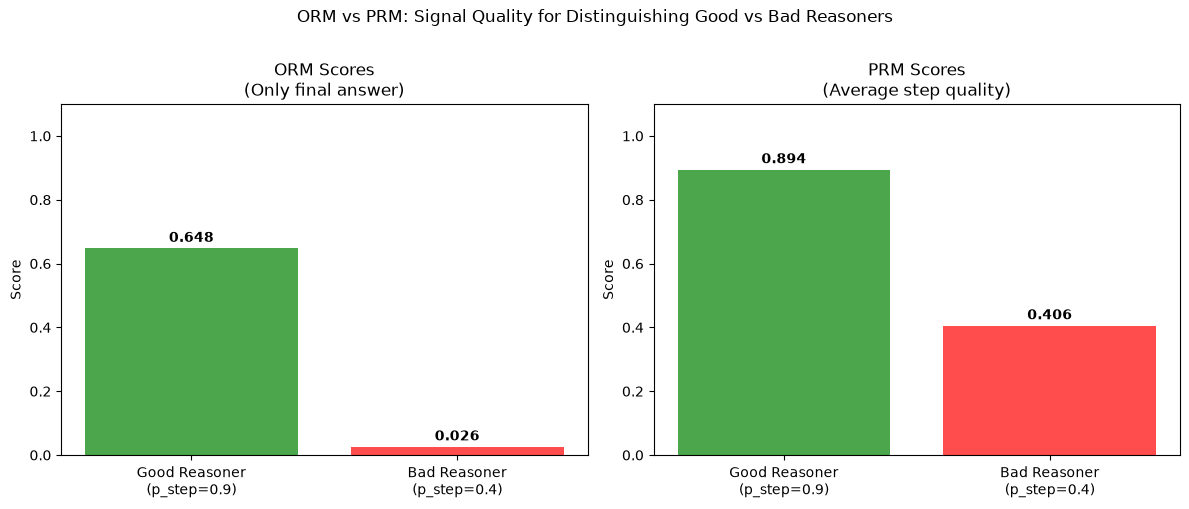

ORM separation (good-bad): 0.622
PRM separation (good-bad): 0.489

PRM gives 0.8x better signal than ORM for distinguishing reasoning quality.


In [5]:
# Simulate ORM vs PRM scoring on reasoning traces
# Trace: list of (step, is_correct) tuples

def generate_traces(n_traces, n_steps, p_step_correct):
    """Generate reasoning traces with per-step correctness labels."""
    traces = []
    for _ in range(n_traces):
        trace = [(f'step_{i}', np.random.random() < p_step_correct) for i in range(n_steps)]
        final_correct = all(s[1] for s in trace)  # correct only if all steps correct
        traces.append({'steps': trace, 'final_correct': final_correct})
    return traces

# Generate good (p=0.9) and bad (p=0.4) reasoners
good_traces = generate_traces(500, 4, p_step_correct=0.90)
bad_traces  = generate_traces(500, 4, p_step_correct=0.40)

# ORM score: 1 if final answer correct, 0 if not
orm_good = np.mean([t['final_correct'] for t in good_traces])
orm_bad  = np.mean([t['final_correct'] for t in bad_traces])

# PRM score: fraction of steps correct
prm_good = np.mean([np.mean([s[1] for s in t['steps']]) for t in good_traces])
prm_bad  = np.mean([np.mean([s[1] for s in t['steps']]) for t in bad_traces])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution of ORM scores
axes[0].bar(['Good Reasoner\n(p_step=0.9)', 'Bad Reasoner\n(p_step=0.4)'],
             [orm_good, orm_bad], color=['green', 'red'], alpha=0.7)
axes[0].set_title('ORM Scores\n(Only final answer)')
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.1)
for i, v in enumerate([orm_good, orm_bad]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Distribution of PRM scores
axes[1].bar(['Good Reasoner\n(p_step=0.9)', 'Bad Reasoner\n(p_step=0.4)'],
             [prm_good, prm_bad], color=['green', 'red'], alpha=0.7)
axes[1].set_title('PRM Scores\n(Average step quality)')
axes[1].set_ylabel('Score'); axes[1].set_ylim(0, 1.1)
for i, v in enumerate([prm_good, prm_bad]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('ORM vs PRM: Signal Quality for Distinguishing Good vs Bad Reasoners', y=1.01)
plt.tight_layout(); plt.show()

orm_delta = orm_good - orm_bad
prm_delta = prm_good - prm_bad
print(f'ORM separation (good-bad): {orm_delta:.3f}')
print(f'PRM separation (good-bad): {prm_delta:.3f}')
print(f'\nPRM gives {prm_delta/orm_delta:.1f}x better signal than ORM for distinguishing reasoning quality.')

## 5. Best-of-N — Sample and Score

**Best-of-N** (also called rejection sampling or BoN) is one of the simplest test-time compute methods:

1. Generate $N$ candidate answers (with or without CoT)
2. Score each with a reward model
3. Return the highest-scoring answer

$$\hat{y}_{BoN} = \arg\max_{i \in \{1,\ldots,N\}} R(x, y_i)$$

**Theoretical improvement:** If each answer is correct with probability $p$, then:

$$P(\text{at least one correct in N}) = 1 - (1-p)^N$$

But this is the **oracle** BoN (assuming a perfect reward model). With a noisy reward model, improvements saturate faster.

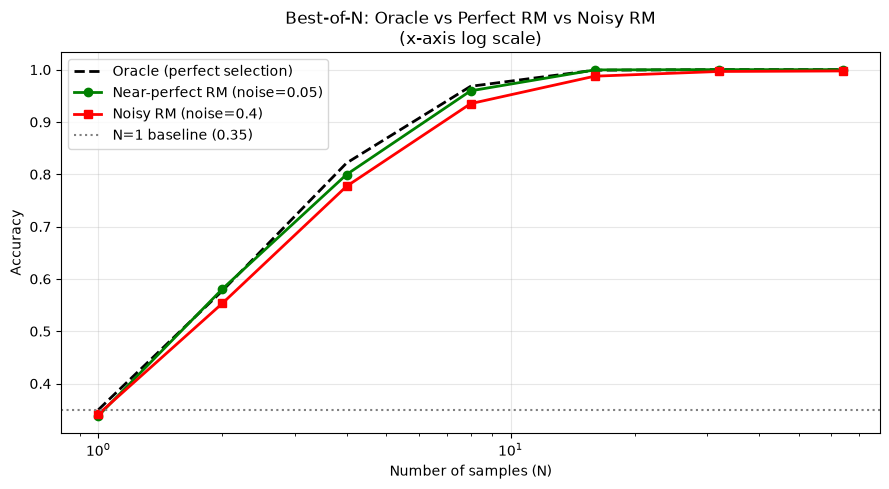

p_base = 0.35

N=32: Oracle=1.000, Perfect RM=1.000, Noisy RM=0.997

Key lesson: RM quality is the bottleneck for Best-of-N. A noisy RM wastes test-time compute.


In [6]:
def best_of_n(true_answer, N, p_correct, reward_noise=0.1):
    """
    Sample N answers, use a noisy reward model to pick the best.
    reward_noise: how often the reward model picks wrong (higher = worse RM)
    """
    answers = []
    for _ in range(N):
        if np.random.random() < p_correct:
            answers.append(true_answer)
        else:
            answers.append(true_answer + np.random.choice([-3,-2,-1,1,2,3]))
    
    # Noisy reward model: score correct answers higher, but sometimes ranks wrong
    def reward(ans):
        base = 1.0 if ans == true_answer else 0.0
        return base + np.random.normal(0, reward_noise)
    
    best_ans = max(answers, key=reward)
    return best_ans, best_ans == true_answer

p_base = 0.35  # hard problem, 35% per sample
N_values = [1, 2, 4, 8, 16, 32, 64]
n_trials = 2000

results_bon = {'oracle': [], 'perfect_rm': [], 'noisy_rm': []}
for N in N_values:
    # Oracle: 1 - (1-p)^N
    results_bon['oracle'].append(1 - (1 - p_base) ** N)
    # Perfect RM
    correct_perfect = sum(1 for _ in range(n_trials) if best_of_n(10, N, p_base, reward_noise=0.05)[1])
    results_bon['perfect_rm'].append(correct_perfect / n_trials)
    # Noisy RM
    correct_noisy = sum(1 for _ in range(n_trials) if best_of_n(10, N, p_base, reward_noise=0.4)[1])
    results_bon['noisy_rm'].append(correct_noisy / n_trials)

plt.figure(figsize=(9, 5))
plt.semilogx(N_values, results_bon['oracle'], 'k--', label='Oracle (perfect selection)', linewidth=2)
plt.semilogx(N_values, results_bon['perfect_rm'], 'g-o', label='Near-perfect RM (noise=0.05)', linewidth=2)
plt.semilogx(N_values, results_bon['noisy_rm'], 'r-s', label='Noisy RM (noise=0.4)', linewidth=2)
plt.axhline(p_base, color='gray', linestyle=':', label=f'N=1 baseline ({p_base})')
plt.xlabel('Number of samples (N)'); plt.ylabel('Accuracy')
plt.title('Best-of-N: Oracle vs Perfect RM vs Noisy RM\n(x-axis log scale)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'p_base = {p_base}')
print(f'\nN=32: Oracle={results_bon["oracle"][-2]:.3f}, Perfect RM={results_bon["perfect_rm"][-2]:.3f}, Noisy RM={results_bon["noisy_rm"][-2]:.3f}')
print('\nKey lesson: RM quality is the bottleneck for Best-of-N. A noisy RM wastes test-time compute.')

## 6. Monte Carlo Tree Search (MCTS) for Reasoning

MCTS adapts the game-playing algorithm (used in AlphaGo) to reasoning:

- **State:** Partial reasoning trace so far
- **Action:** Next reasoning step
- **Reward:** PRM score at each step or final ORM score

**MCTS Loop:**
1. **Select:** Traverse tree using UCB1 to balance exploration/exploitation
2. **Expand:** Add new child nodes (possible next steps)
3. **Simulate:** Random rollout from new node to terminal state
4. **Backpropagate:** Update node values along the path

$$\text{UCB1}(v) = \bar{Q}(v) + c \sqrt{\frac{\ln N(\text{parent})}{N(v)}}$$

Comparing methods on 200 problems (3 ops each)...


  Direct         : 0.770
  Best-of-8      : 1.000
  Self-Cons-8    : 1.000
  MCTS-100       : 1.000


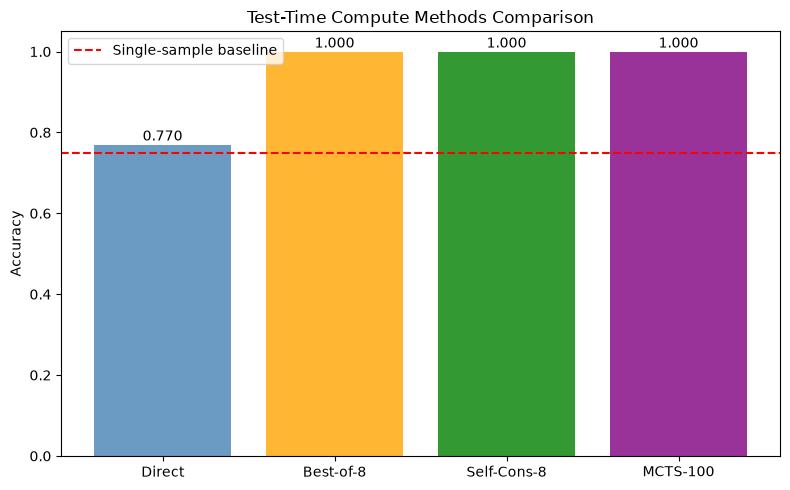

In [7]:
class MCTSNode:
    def __init__(self, state, parent=None, step_correct=True):
        self.state = state          # current value after this step
        self.parent = parent
        self.children = []
        self.visits = 0
        self.total_value = 0.0
        self.step_correct = step_correct  # was this step correct?
    
    @property
    def avg_value(self):
        return self.total_value / self.visits if self.visits > 0 else 0.0
    
    def ucb1(self, c=1.4):
        if self.visits == 0: return float('inf')
        parent_visits = self.parent.visits if self.parent else 1
        return self.avg_value + c * np.sqrt(np.log(parent_visits) / self.visits)
    
    def is_leaf(self):
        return len(self.children) == 0

def mcts_reasoning(true_answer, n_ops, n_iterations=200, branching=3, p_step=0.80):
    """MCTS over a multi-step arithmetic problem."""
    expr, ans, problem_steps = generate_problem(n_ops=n_ops, seed=42)
    start_val = int(expr.split()[0])
    root = MCTSNode(state={'value': start_val, 'step': 0})
    
    def simulate_rollout(node, depth_remaining):
        """Random rollout from node."""
        if depth_remaining == 0:
            return 1.0 if node.state['value'] == true_answer else 0.0
        # Random step: branch toward correct answer sometimes
        if np.random.random() < p_step:
            next_val = true_answer if depth_remaining == 1 else node.state['value'] + np.random.randint(-2,3)
        else:
            next_val = node.state['value'] + np.random.randint(-4, 5)
        next_state = {'value': next_val, 'step': node.state['step'] + 1}
        child = MCTSNode(next_state, parent=node)
        return simulate_rollout(child, depth_remaining - 1)
    
    def select(node):
        """Select best child by UCB1."""
        while not node.is_leaf():
            node = max(node.children, key=lambda c: c.ucb1())
        return node
    
    def expand(node):
        """Add branching=3 children."""
        step = node.state['step']
        if step >= n_ops: return
        for _ in range(branching):
            # Simulate possible next steps
            if np.random.random() < p_step:
                next_val = true_answer if step == n_ops - 1 else node.state['value'] + np.random.randint(-1,2)
                correct = True
            else:
                next_val = node.state['value'] + np.random.choice([-4,-3,-2,2,3,4])
                correct = False
            child = MCTSNode({'value': next_val, 'step': step+1}, parent=node, step_correct=correct)
            node.children.append(child)
    
    def backprop(node, value):
        while node:
            node.visits += 1
            node.total_value += value
            node = node.parent
    
    # Main MCTS loop
    for _ in range(n_iterations):
        leaf = select(root)
        expand(leaf)
        if leaf.children:
            new_node = random.choice(leaf.children)
            value = simulate_rollout(new_node, n_ops - new_node.state['step'])
            backprop(new_node, value)
        else:
            value = 1.0 if leaf.state['value'] == true_answer else 0.0
            backprop(leaf, value)
    
    # Best path: follow highest-value children
    path = [root]
    node = root
    while node.children:
        best_child = max(node.children, key=lambda c: c.avg_value)
        path.append(best_child)
        node = best_child
    
    final_val = path[-1].state['value']
    return root, path, final_val == true_answer

def compare_methods(n_problems=200, n_ops=3):
    """Compare Direct, BoN, Self-Consistency, MCTS."""
    p_single = 0.75
    direct_acc, bon_acc, sc_acc, mcts_acc = 0, 0, 0, 0
    for trial in range(n_problems):
        expr, ans, steps = generate_problem(n_ops=n_ops, seed=trial)
        # Direct
        _, ok = simulate_direct(ans, p_correct=p_single)
        direct_acc += ok
        # BoN-8
        _, ok = best_of_n(ans, N=8, p_correct=p_single, reward_noise=0.1)
        bon_acc += ok
        # Self-consistency-8
        votes = [ans if np.random.random() < p_single else ans + np.random.randint(-3,4) for _ in range(8)]
        sc_acc += (Counter(votes).most_common(1)[0][0] == ans)
        # MCTS-100
        _, _, ok = mcts_reasoning(ans, n_ops=n_ops, n_iterations=100, p_step=0.87)
        mcts_acc += ok
    return {k: v/n_problems for k, v in [('Direct', direct_acc), ('Best-of-8', bon_acc),
                                          ('Self-Cons-8', sc_acc), ('MCTS-100', mcts_acc)]}

print('Comparing methods on 200 problems (3 ops each)...')
method_results = compare_methods()
for m, a in method_results.items(): print(f'  {m:<15}: {a:.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(method_results.keys()), list(method_results.values()),
              color=['steelblue', 'orange', 'green', 'purple'], alpha=0.8)
ax.axhline(0.75, color='red', linestyle='--', label='Single-sample baseline')
for bar, v in zip(bars, method_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.3f}', ha='center')
ax.set_ylabel('Accuracy'); ax.set_title('Test-Time Compute Methods Comparison')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Scaling Test-Time Compute — The Compute Tradeoff

A key insight from recent research (Snell et al., 2024; Google DeepMind, 2024):

> For a fixed **inference budget**, is it better to use a *larger model* (more training compute) or *more samples at inference* (more test-time compute)?

**Result:** For harder problems, investing in test-time compute often beats model scaling.

$$\text{Compute budget} = C_{\text{train}} + N \cdot C_{\text{inference}}$$

This suggests we should **adaptively allocate inference compute** — easy problems get few samples, hard problems get many.

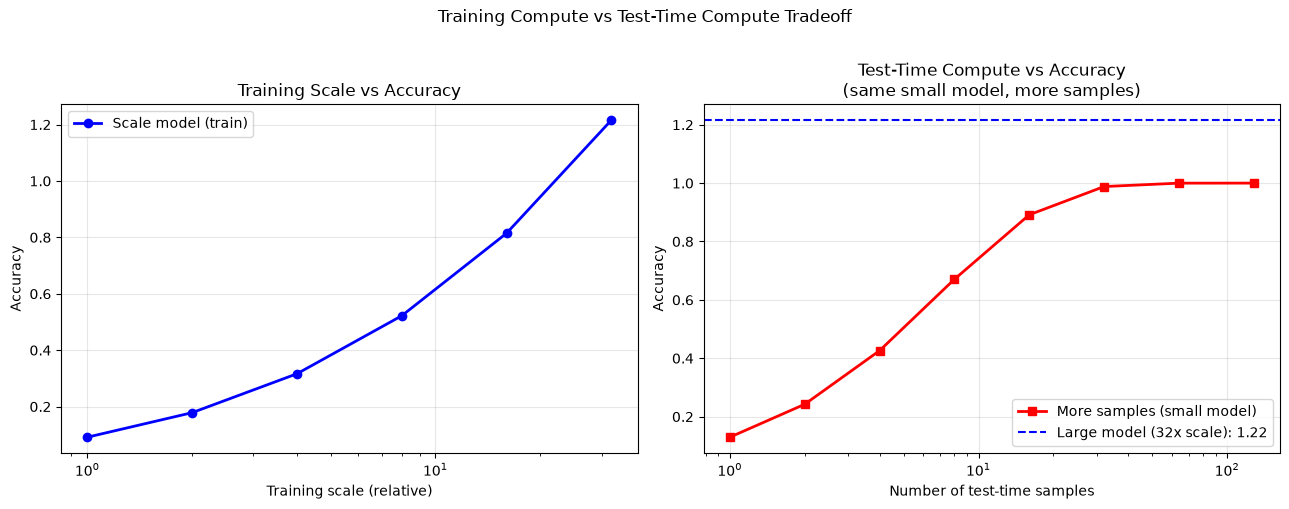

Adaptive allocation: easy problems need N=1, hard problems need N=64+
This motivates models like o1/o3 that can "think more" on hard problems.


In [8]:
# Simulate scaling laws: training compute vs test-time compute
# Assumption: bigger model has higher p_single; more test-time = more BoN/SC

def model_accuracy(training_scale, n_ops):
    """Simulate how model scale (1x, 2x, 4x, 8x) affects per-step accuracy."""
    base_p = 0.55 + 0.1 * np.log2(training_scale)
    return base_p ** n_ops

def test_time_accuracy(base_p_per_step, N_samples, n_ops):
    """Best-of-N with a perfect RM."""
    p_single = base_p_per_step ** n_ops
    return 1 - (1 - p_single) ** N_samples

N_OPS = 4
base_p_small = 0.60  # small model per-step accuracy

# Fixed budget: can spend it on training scale OR test-time N
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scaling curve — training compute vs test-time compute
train_scales = [1, 2, 4, 8, 16, 32]
train_accs = [model_accuracy(s, N_OPS) for s in train_scales]
axes[0].semilogx(train_scales, train_accs, 'b-o', label='Scale model (train)', linewidth=2)
axes[0].set_xlabel('Training scale (relative)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training Scale vs Accuracy')
axes[0].grid(alpha=0.3); axes[0].legend()

# Right: test-time compute scaling for same small model
N_samples = [1, 2, 4, 8, 16, 32, 64, 128]
tt_accs = [test_time_accuracy(base_p_small, N, N_OPS) for N in N_samples]
axes[1].semilogx(N_samples, tt_accs, 'r-s', label='More samples (small model)', linewidth=2)
axes[1].axhline(train_accs[-1], color='blue', linestyle='--', label=f'Large model (32x scale): {train_accs[-1]:.2f}')
axes[1].set_xlabel('Number of test-time samples')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test-Time Compute vs Accuracy\n(same small model, more samples)')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('Training Compute vs Test-Time Compute Tradeoff', y=1.01)
plt.tight_layout(); plt.show()

print('Adaptive allocation: easy problems need N=1, hard problems need N=64+')
print('This motivates models like o1/o3 that can "think more" on hard problems.')

## 8. Summary — Reasoning Model Landscape

### Taxonomy of Test-Time Compute Methods

```
               Parallel sampling              Sequential refinement
               ┌─────────────────┐           ┌──────────────────────┐
 Single path   │ Direct answer   │           │ Self-refinement      │
               │ Greedy CoT      │           │ (critique & revise)  │
               └─────────────────┘           └──────────────────────┘
 Multiple paths│ Self-consistency │           │ MCTS / beam search   │
               │ Best-of-N       │           │ Lookahead            │
               │ Diverse sampling│           │ Stepwise RL          │
               └─────────────────┘           └──────────────────────┘
```

### When to Use Each

| Method | Best For | Compute Cost | Requires |
|--------|----------|-------------|----------|
| CoT | Reasoning tasks | 1–3× | Prompt engineering |
| Self-Consistency | Multiple solution paths | N× | Nothing extra |
| Best-of-N | Answer verification easy | N× | Reward model |
| PRM-guided | Step-level quality | N× | Trained PRM |
| MCTS | Structured search space | High | PRM + many samples |

### Real-World Models
- **OpenAI o1/o3**: Extended CoT (visible), RL-trained on reasoning traces
- **DeepSeek-R1**: Open-source reasoning model with visible thinking
- **Google Gemini Flash Thinking**: Visible reasoning traces
- **Anthropic Claude**: Internal reasoning via Extended Thinking API

## Additional Resources

1. **Chain-of-Thought Prompting** (Wei et al., 2022) — https://arxiv.org/abs/2201.11903 — Original CoT paper
2. **Self-Consistency** (Wang et al., 2022) — https://arxiv.org/abs/2203.11171 — Majority voting over CoT
3. **Let's Verify Step by Step** (Lightman et al., 2023) — https://arxiv.org/abs/2305.20050 — PRM vs ORM at scale
4. **Scaling LLM Test-Time Compute** (Snell et al., 2024) — https://arxiv.org/abs/2408.03314 — Compute-optimal inference
5. **rStar-Math** (Guan et al., 2025) — MCTS + PRM for math reasoning
6. **DeepSeek-R1** (DeepSeek, 2025) — https://arxiv.org/abs/2501.12948 — Open-source reasoning model
7. **OpenAI o1 System Card** — https://openai.com/index/openai-o1-system-card/ — Details on the o1 model
8. **Reward Model Ensembles Help Mitigate Overoptimization** (Coste et al., 2023) — Reward hacking in BoN